## Seasonality analysis
Code for seasonal plot and periodogram from: https://www.kaggle.com/code/ryanholbrook/seasonality#Example---Tunnel-Traffic

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="deep")

ModuleNotFoundError: No module named 'seaborn'

In [2]:
data_dir = Path("./data/")

df = pd.read_csv(
    data_dir / "ED18_03112023.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).drop(
    [
        "_id",
        "unit_id",
        "rounded_datatime",
    ],
    axis=1,
)

# equivalent but more verbose: df = ed18_data.loc[:, "TotVA"].to_frame() 
df = df[["TotVA"]]

print(f'Dropping NaN {df.loc[:, "TotVA"].isna().sum()} values.')
df = df.dropna()

Dropping NaN 174 values.


In [3]:
def seasonal_plot(X, y, period="week", freq="day", ax=None):
    if ax is None:
        _, ax = plt.subplots()

    palette = sns.color_palette("husl", n_colors=X[period].nunique())

    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        errorbar=("ci", False),
        ax=ax,
        palette=palette,
        legend="",
    )

    ax.set_title(f"Seasonal Plot ({period}/{freq})")

    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )

    return ax

In [4]:
def plot_periodogram(ts, detrend='linear', ax=None, figsize=(15, 5)):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

## Seasonal plot

To differently colored lines correspond different (numbered) weeks. Each point on the x axis refers to a day of the week (mon-sun), while the y axis tracks the TotVA on each day, for each week. 

In the following plot, we can confirm a kind of weekly seasonality by noticing how many lines (weeks) act in a similar way.

/tmp/ipykernel_29541/510015433.py:10: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  X["week"] = X.index.week      # type: ignore


<Axes: title={'center': 'Seasonal Plot (week/day)'}, xlabel='day', ylabel='TotVA'>

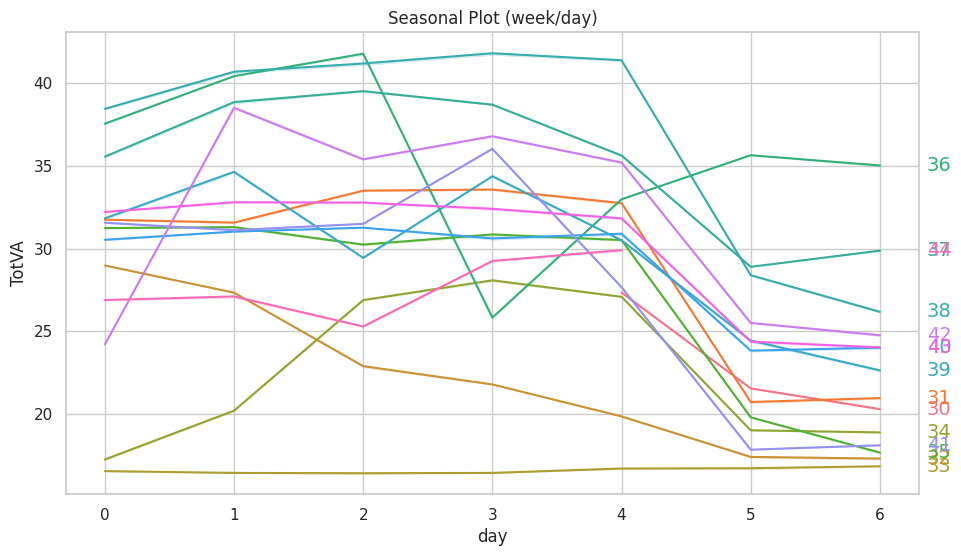

In [5]:
# create a time-step feature
df["time"] = np.arange(len(df.index))

# create data for seasonal plot
X = df.loc[:, ["time"]]
y = df.loc[:, "TotW"]

# build features for seasonal plot: freq (x axis) and seasonal period ("range" of plot)
X["day"] = X.index.dayofweek  # type: ignore 
X["week"] = X.index.week      # type: ignore

fig, ax = plt.subplots(figsize=(11, 6))
seasonal_plot(X, y=y, period="week", freq="day", ax=ax)

## Periodogram

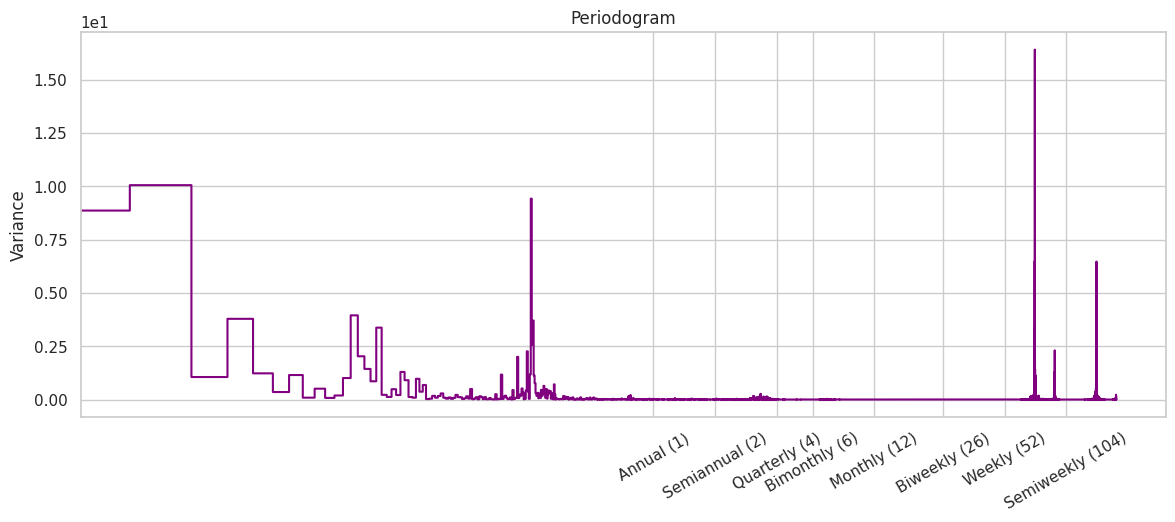

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax = plot_periodogram(y, ax=ax)

## Deaseasonalization

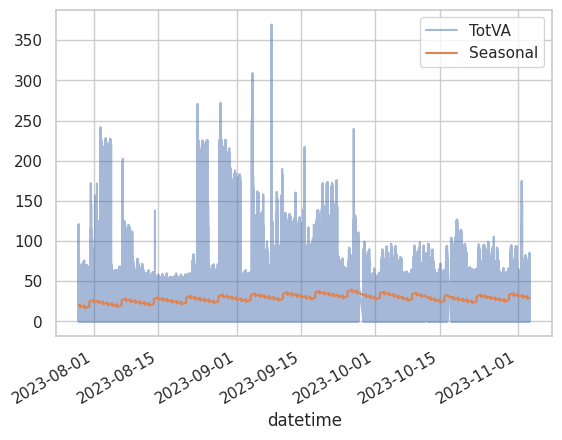

In [9]:
model = LinearRegression().fit(X, y)

y_pred = pd.Series(
    model.predict(X),
    index=X.index,
)

y_pred = pd.Series(model.predict(X), index=X.index)
ax = y.plot(alpha=0.5)
ax = y_pred.plot(ax=ax, label="Seasonal")
ax.legend()

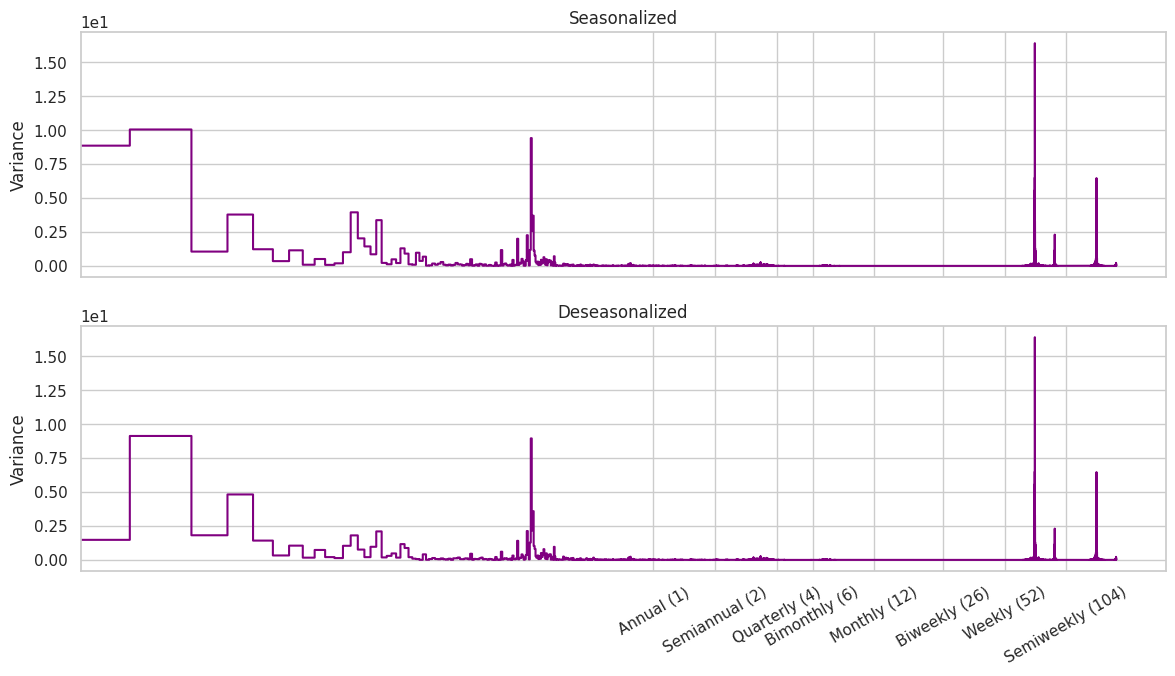

In [16]:
y_deseason = y - y_pred

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(14, 7))
ax1 = plot_periodogram(y, ax=ax1)
ax1.set_title("Seasonalized")
ax2 = plot_periodogram(y_deseason, ax=ax2);
ax2.set_title("Deseasonalized");